In [5]:
# Cài đặt thư viện nếu chưa có: !pip install pandas matplotlib seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# ==========================================
# THIẾT LẬP FORMAT CHUẨN IEEE / SPRINGER
# ==========================================
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'axes.titleweight': 'semibold',
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.linewidth': 1.1,
    'lines.linewidth': 2.0,
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
    'figure.facecolor': 'white',
    'axes.facecolor': '#fcfcfc',
    'axes.edgecolor': '#2f2f2f',
    'legend.frameon': True,
    'legend.edgecolor': '#444444',
    'savefig.dpi': 300,
    'savefig.format': 'pdf',
    'savefig.bbox': 'tight',
})
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])

# Tạo thư mục lưu biểu đồ
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)



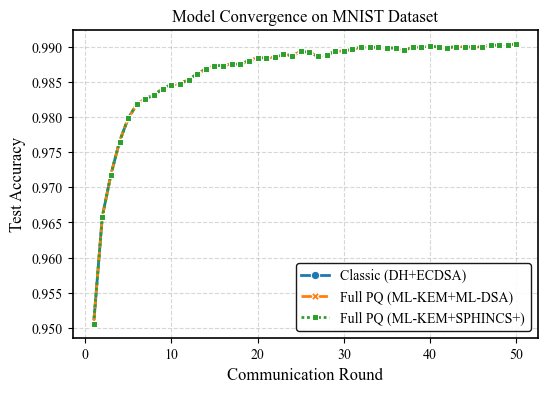

Đã lưu đồ thị tại: figures\fig1_convergence.pdf


In [3]:
# ==========================================
# ĐỒ THỊ 1: FEDERATED LEARNING ACCURACY
# ==========================================
# Đọc dữ liệu (Đảm bảo đường dẫn đúng với file của bạn)
try:
    df_acc = pd.read_csv("results/bench_accuracy.csv")
    
    # Tạo figure kích thước chuẩn 1 cột của IEEE (khoảng 3.5 inches, nhưng ở đây để 6x4 cho dễ nhìn trên màn hình)
    fig, ax = plt.subplots(figsize=(6, 4))
    
    # Vẽ đường biểu diễn
    sns.lineplot(
        data=df_acc, 
        x="round", 
        y="accuracy", 
        hue="backend_label", 
        style="backend_label", 
        markers=True, 
        dashes=True,
        ax=ax,
        palette="tab10" # Bảng màu chuẩn
    )
    
    ax.set_xlabel("Communication Round")
    ax.set_ylabel("Test Accuracy")
    ax.set_title("Model Convergence on MNIST Dataset")
    ax.grid(True)
    
    # Chỉnh lại Legend cho đẹp
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=labels, loc="lower right", framealpha=0.9, edgecolor='black')
    
    # Lưu file
    fig_path = FIG_DIR / "fig1_convergence.pdf"
    plt.savefig(fig_path)
    plt.show()
    print(f"Đã lưu đồ thị tại: {fig_path}")

except FileNotFoundError:
    print("Không tìm thấy file bench_accuracy.csv. Hãy kiểm tra lại đường dẫn!")

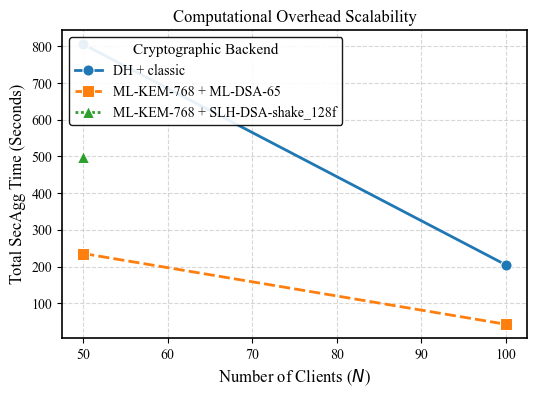

Đã lưu đồ thị tại: figures\fig2_scalability.pdf


In [3]:
# ==========================================
# ĐỒ THỊ 2: SCALABILITY TÍNH TOÁN (TIME VS N_CLIENTS)
# ==========================================
try:
    df_scale = pd.read_csv("results/bench_scalability_sig.csv")
    
    # Gom nhóm theo n_clients và backend, sau đó TÍNH TỔNG thời gian của tất cả các phase
    df_scale['backend_combo'] = df_scale['kem_backend'] + " + " + df_scale['sig_backend']
    df_total_time = df_scale.groupby(['n_clients', 'backend_combo'])['time_sec'].sum().reset_index()
    
    fig, ax = plt.subplots(figsize=(6, 4))
    
    sns.lineplot(
        data=df_total_time, 
        x="n_clients", 
        y="time_sec", 
        hue="backend_combo", 
        style="backend_combo", 
        markers=["o", "s", "^", "D", "X"][:len(df_total_time['backend_combo'].unique())], 
        markersize=8,
        ax=ax
    )
    
    ax.set_xlabel("Number of Clients ($N$)")
    ax.set_ylabel("Total SecAgg Time (Seconds)")
    ax.set_title("Computational Overhead Scalability")
    ax.grid(True)
    
    ax.legend(title="Cryptographic Backend", loc="upper left", framealpha=0.9, edgecolor='black')
    
    fig_path = FIG_DIR / "fig2_scalability.pdf"
    plt.savefig(fig_path)
    plt.show()
    print(f"Đã lưu đồ thị tại: {fig_path}")

except FileNotFoundError:
    print("Không tìm thấy file bench_scalability.csv")

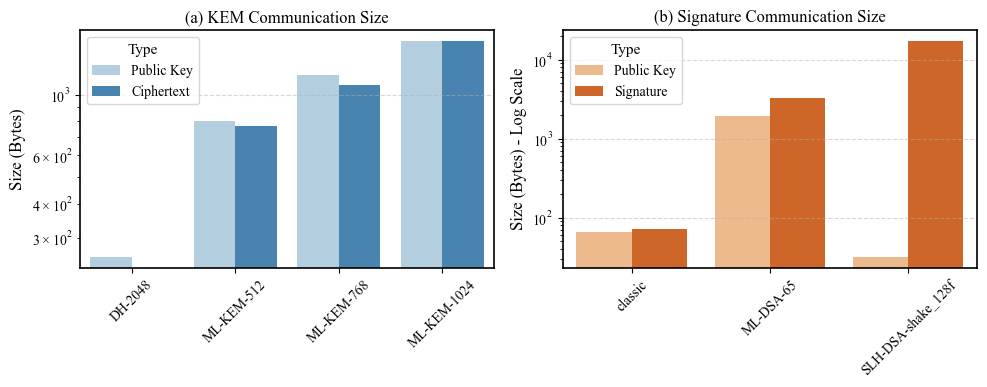

Đã lưu đồ thị tại: figures\fig3_communication.pdf


In [4]:
# ==========================================
# ĐỒ THỊ 3: COMMUNICATION OVERHEAD (SIZE IN BYTES)
# ==========================================
try:
    df_kem = pd.read_csv("results/bench_crypto_kem.csv")
    df_sig = pd.read_csv("results/bench_crypto_sig.csv")

    sig_plot = df_sig.copy()
    if "backend" not in sig_plot.columns and "sig_backend" in sig_plot.columns:
        sig_plot = sig_plot.rename(columns={"sig_backend": "backend"})

    kem_plot = df_kem.copy()
    if "backend" not in kem_plot.columns and "kem_backend" in kem_plot.columns:
        kem_plot = kem_plot.rename(columns={"kem_backend": "backend"})

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    kem_cols = [c for c in ["pk_bytes", "ct_bytes"] if c in kem_plot.columns]
    if kem_cols:
        kem_melt = kem_plot.melt(
            id_vars="backend",
            value_vars=kem_cols,
            var_name="Type",
            value_name="Bytes",
        )
        kem_melt["Type"] = kem_melt["Type"].map({"pk_bytes": "Public Key", "ct_bytes": "Ciphertext"})
        sns.barplot(data=kem_melt, x="backend", y="Bytes", hue="Type", ax=axes[0], palette="Blues")
        axes[0].set_title("(a) KEM Communication Size")
        axes[0].set_ylabel("Size (Bytes)")
        axes[0].set_xlabel("")
        axes[0].tick_params(axis="x", rotation=45)
        axes[0].grid(axis="y")
        axes[0].set_yscale("log")
    else:
        axes[0].text(0.5, 0.5, "bench_crypto_kem.csv\nmissing expected columns", ha="center", va="center")
        axes[0].axis("off")

    sig_cols = [c for c in ["pk_bytes", "sig_bytes"] if c in sig_plot.columns]
    if sig_cols:
        sig_melt = sig_plot.melt(
            id_vars="backend",
            value_vars=sig_cols,
            var_name="Type",
            value_name="Bytes",
        )
        sig_melt["Type"] = sig_melt["Type"].map({"pk_bytes": "Public Key", "sig_bytes": "Signature"})
        if "backend" in sig_melt.columns:
            sig_melt = sig_melt[sig_melt["backend"].isin(["classic", "ML-DSA-65", "SLH-DSA-shake_128f"])]
        sns.barplot(data=sig_melt, x="backend", y="Bytes", hue="Type", ax=axes[1], palette="Oranges")
        axes[1].set_title("(b) Signature Communication Size")
        axes[1].set_ylabel("Size (Bytes) - Log Scale")
        axes[1].set_xlabel("")
        axes[1].tick_params(axis="x", rotation=45)
        axes[1].grid(axis="y")
        axes[1].set_yscale("log")
    else:
        axes[1].text(0.5, 0.5, "bench_crypto_sig.csv\nmissing expected columns", ha="center", va="center")
        axes[1].axis("off")

    plt.tight_layout()
    fig_path = FIG_DIR / "fig3_communication.pdf"
    plt.savefig(fig_path)
    plt.show()
    print(f"Đã lưu đồ thị tại: {fig_path}")

except FileNotFoundError:
    print("Không tìm thấy các file bench_crypto_*.csv")

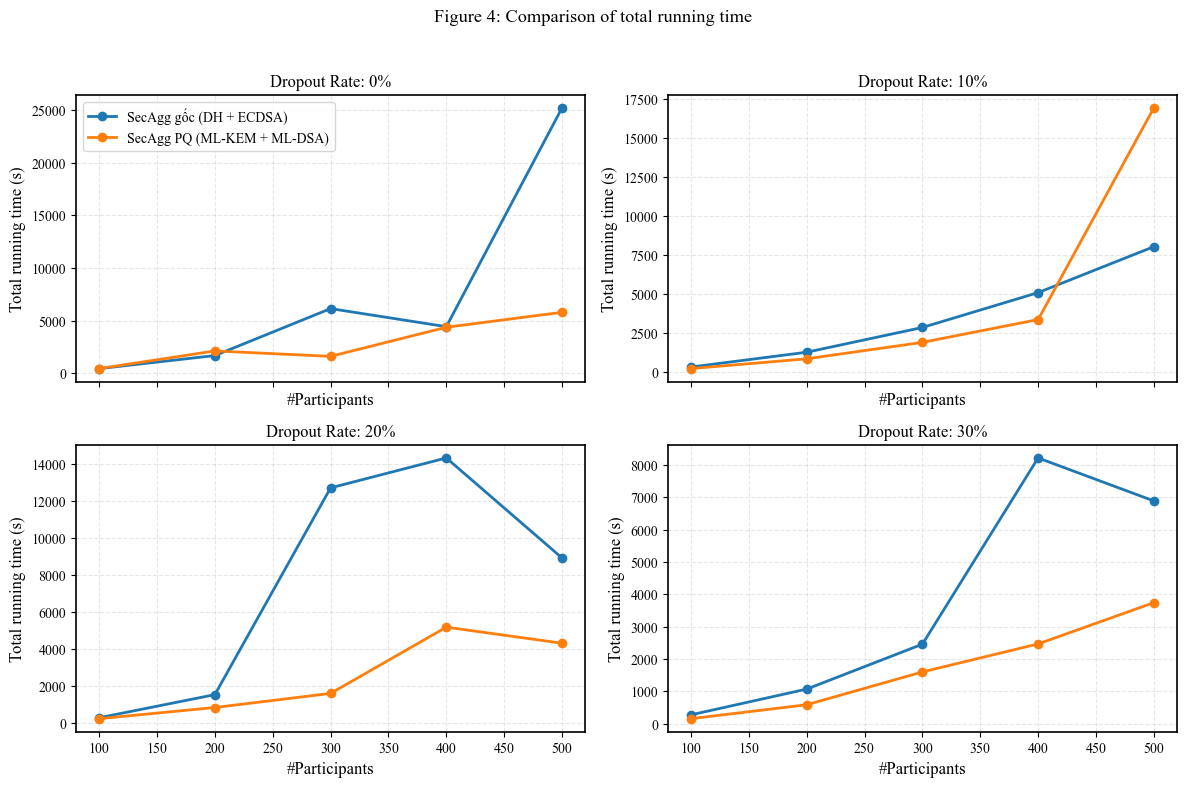

Đã lưu: figures\fig4_runtime_clients.pdf


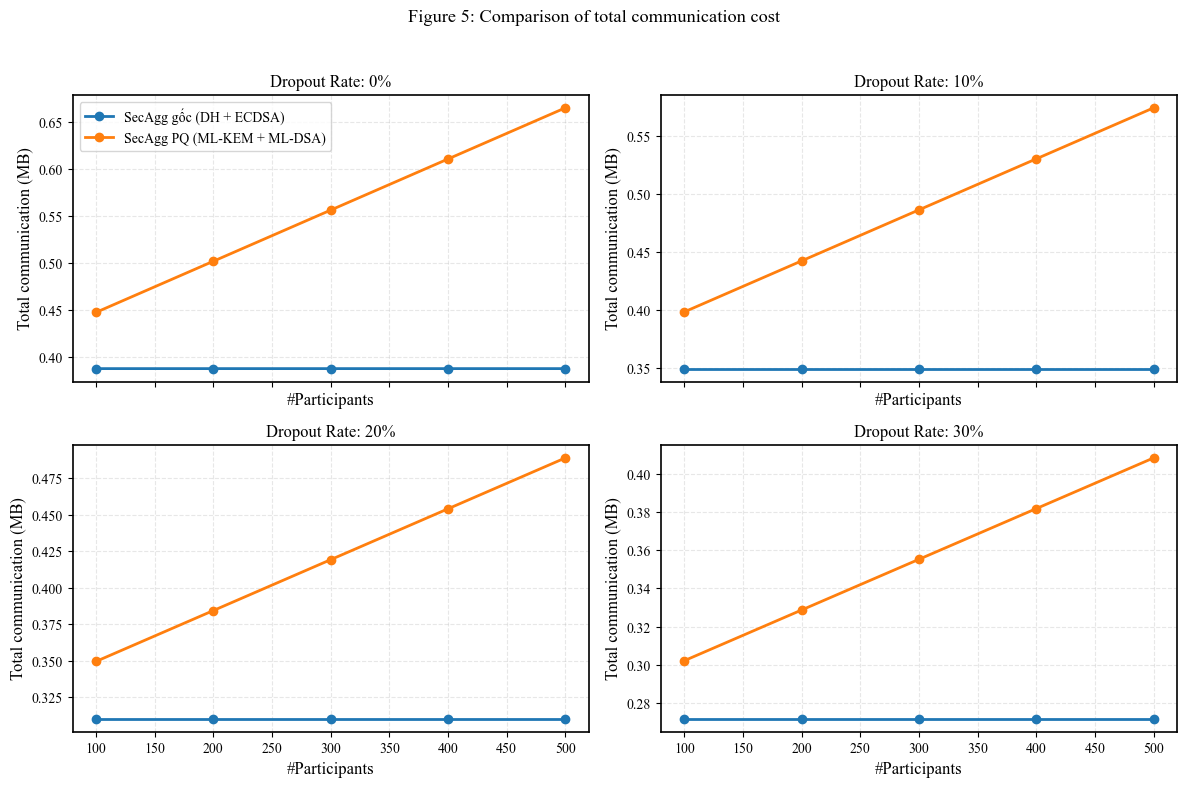

Đã lưu: figures\fig5_comm_clients.pdf


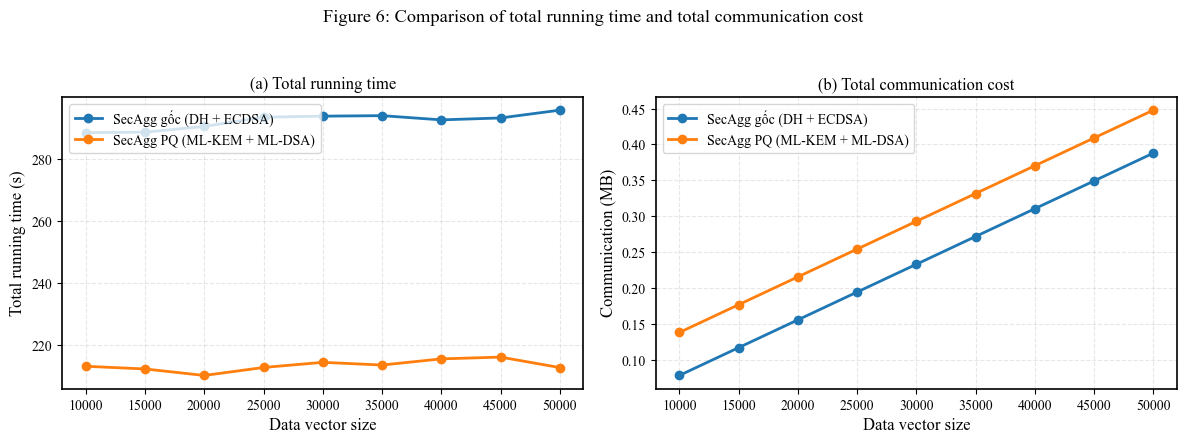

Đã lưu: figures\fig6_runtime_comm_vector.pdf


In [2]:
# ==========================================
# ĐỒ THỊ 4: BENCHMARK 3 - ORIGINAL VS PQ
# ==========================================
summary_path = Path("results/bench_orig_vs_pq_summary.csv")

if not summary_path.exists():
    print(f"Không tìm thấy file {summary_path}. Hãy chạy bench_orig_vs_pq.py trước.")
else:
    df = pd.read_csv(summary_path)
    df["dropout_pct"] = (df["dropout_rate"] * 100).round().astype(int)

    color_map = {
        "original": "tab:blue",
        "pq": "tab:orange",
    }
    label_map = {
        "original": "SecAgg gốc (DH + ECDSA)",
        "pq": "SecAgg PQ (ML-KEM + ML-DSA)",
    }

    # Figure 4: Total runtime vs participants, grouped by dropout rate
    clients_df = df[df["scenario"] == "clients"].copy()
    dropout_values = sorted(clients_df["dropout_pct"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=False)
    axes = axes.flatten()

    for axis, dropout_pct in zip(axes, dropout_values):
        subset = clients_df[clients_df["dropout_pct"] == dropout_pct]
        for algorithm in ["original", "pq"]:
            alg_subset = subset[subset["algorithm"] == algorithm].sort_values("n_clients")
            axis.plot(
                alg_subset["n_clients"],
                alg_subset["total_time_sec"],
                marker="o",
                linewidth=2,
                color=color_map[algorithm],
                label=label_map[algorithm],
            )
        axis.set_title(f"Dropout Rate: {dropout_pct}%")
        axis.set_xlabel("#Participants")
        axis.set_ylabel("Total running time (s)")
        axis.grid(True, alpha=0.3)

    axes[0].legend(frameon=True, loc="upper left")
    fig.suptitle("Figure 4: Comparison of total running time")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig_path = FIG_DIR / "fig4_runtime_clients.pdf"
    fig.savefig(fig_path, bbox_inches="tight")
    plt.show()
    print(f"Đã lưu: {fig_path}")

    # Figure 5: Total communication vs participants, grouped by dropout rate
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=False)
    axes = axes.flatten()

    for axis, dropout_pct in zip(axes, dropout_values):
        subset = clients_df[clients_df["dropout_pct"] == dropout_pct]
        for algorithm in ["original", "pq"]:
            alg_subset = subset[subset["algorithm"] == algorithm].sort_values("n_clients")
            axis.plot(
                alg_subset["n_clients"],
                alg_subset["total_comm_mb"],
                marker="o",
                linewidth=2,
                color=color_map[algorithm],
                label=label_map[algorithm],
            )
        axis.set_title(f"Dropout Rate: {dropout_pct}%")
        axis.set_xlabel("#Participants")
        axis.set_ylabel("Total communication (MB)")
        axis.grid(True, alpha=0.3)

    axes[0].legend(frameon=True, loc="upper left")
    fig.suptitle("Figure 5: Comparison of total communication cost")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig_path = FIG_DIR / "fig5_comm_clients.pdf"
    fig.savefig(fig_path, bbox_inches="tight")
    plt.show()
    print(f"Đã lưu: {fig_path}")

    # Figure 6: Runtime and communication vs vector size at 100 clients, no dropout
    vector_df = df[df["scenario"] == "vector"].copy().sort_values("vector_size")
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)

    for algorithm in ["original", "pq"]:
        alg_subset = vector_df[vector_df["algorithm"] == algorithm].sort_values("vector_size")
        axes[0].plot(
            alg_subset["vector_size"],
            alg_subset["total_time_sec"],
            marker="o",
            linewidth=2,
            color=color_map[algorithm],
            label=label_map[algorithm],
        )
        axes[1].plot(
            alg_subset["vector_size"],
            alg_subset["total_comm_mb"],
            marker="o",
            linewidth=2,
            color=color_map[algorithm],
            label=label_map[algorithm],
        )

    axes[0].set_title("(a) Total running time")
    axes[0].set_xlabel("Data vector size")
    axes[0].set_ylabel("Total running time (s)")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(frameon=True, loc="upper left")

    axes[1].set_title("(b) Total communication cost")
    axes[1].set_xlabel("Data vector size")
    axes[1].set_ylabel("Communication (MB)")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(frameon=True, loc="upper left")

    fig.suptitle("Figure 6: Comparison of total running time and total communication cost")
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    fig_path = FIG_DIR / "fig6_runtime_comm_vector.pdf"
    fig.savefig(fig_path, bbox_inches="tight")
    plt.show()
    print(f"Đã lưu: {fig_path}")


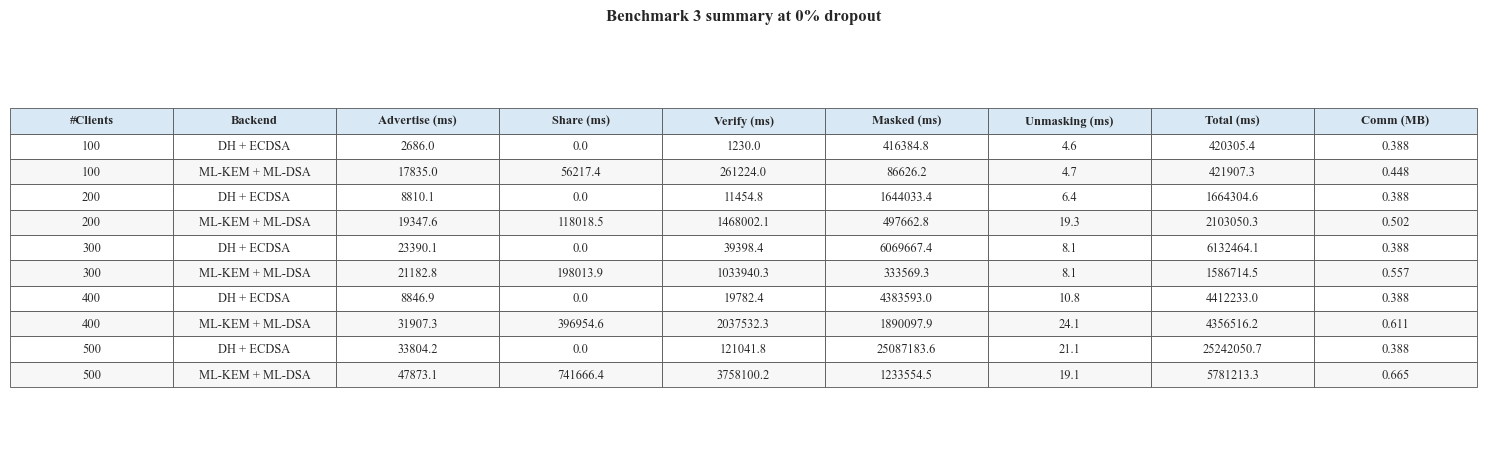

Đã lưu bảng tại: figures\fig7_bench3_summary_table.pdf


In [6]:
# ==========================================
# BẢNG TÓM TẮT BENCHMARK 3
# ==========================================
summary_path = Path("results/bench_orig_vs_pq_summary.csv")

if not summary_path.exists():
    print(f"Không tìm thấy file {summary_path}. Hãy chạy bench_orig_vs_pq.py trước.")
else:
    df = pd.read_csv(summary_path)
    df["dropout_pct"] = (df["dropout_rate"] * 100).round().astype(int)

    def _ms(value):
        return f"{value * 1000:.1f}"

    clients_table = df[(df["scenario"] == "clients") & (df["dropout_pct"] == 0)].copy()
    clients_table["backend"] = clients_table["algorithm"].map({
        "original": "DH + ECDSA",
        "pq": "ML-KEM + ML-DSA",
    })
    clients_table = clients_table.sort_values(["n_clients", "algorithm"])
    clients_table = clients_table[[
        "n_clients", "backend",
        "advertise_keys_sec", "share_keys_sec", "verify_sigs_sec",
        "masked_input_sec", "unmasking_sec", "total_time_sec", "total_comm_mb",
    ]].rename(columns={
        "n_clients": "#Clients",
        "backend": "Backend",
        "advertise_keys_sec": "Advertise (ms)",
        "share_keys_sec": "Share (ms)",
        "verify_sigs_sec": "Verify (ms)",
        "masked_input_sec": "Masked (ms)",
        "unmasking_sec": "Unmasking (ms)",
        "total_time_sec": "Total (ms)",
        "total_comm_mb": "Comm (MB)",
    })

    for column in ["Advertise (ms)", "Share (ms)", "Verify (ms)", "Masked (ms)", "Unmasking (ms)", "Total (ms)"]:
        clients_table[column] = clients_table[column].map(_ms)
    clients_table["Comm (MB)"] = clients_table["Comm (MB)"].map(lambda value: f"{value:.3f}")

    fig, ax = plt.subplots(figsize=(15, 4.8))
    ax.axis("off")
    table = ax.table(
        cellText=clients_table.values,
        colLabels=clients_table.columns,
        cellLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.0, 1.35)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#555555")
        cell.set_linewidth(0.6)
        if row == 0:
            cell.set_facecolor("#d9e8f5")
            cell.set_text_props(weight="bold")
        elif row % 2 == 0:
            cell.set_facecolor("#f7f7f7")

    ax.set_title("Benchmark 3 summary at 0% dropout", pad=14)
    fig.tight_layout()
    fig_path = FIG_DIR / "fig7_bench3_summary_table.pdf"
    fig.savefig(fig_path, bbox_inches="tight")
    plt.show()
    print(f"Đã lưu bảng tại: {fig_path}")
